# IMPORT LIBRARIES

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

In [2]:
# DO NOT RUN THIS CELL IT ONLY CONTAINS MY NOTEBOOK STRUCTURE TEMPLATES TO BE RUN INDIVIDUALLY
# 1, 2, 3 are standard to load and read my data, 4 is where I write my logic, and 5 is where I save the processed data. I run each cell individually as I write my code, and I use this structure to keep me on track and avoid mistakes.


# 1. IMPORTS
##import pandas as pd
##from pathlib import Path

# 2. PATHS (CUSTOMIZE THESE 2 LINES)
##DATA_DIR = Path('../data')
##INPUT_FILE = DATA_DIR / 'df_eda_features.parquet'          # ← Change input name
##OUTPUT_FILE = DATA_DIR / 'df_features_engineered.parquet'  # ← Change output name

# 3. LOAD
##df = pd.read_parquet(INPUT_FILE)
##print(f"Loaded {df.shape}")

# 4. YOUR LOGIC (WRITE YOUR CODE HERE)
##df_processed = df.copy()
# ... your feature engineering / cleaning / processing ...

# 5. SAVE
##DATA_DIR.mkdir(parents=True, exist_ok=True)
##df_processed.to_parquet(OUTPUT_FILE, index=False)
##print(f"✅ Saved {OUTPUT_FILE}")

In [3]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib; ## Only run once to install dependencies

In [4]:
# 1. IMPORTS
import pandas as pd                     # For data manipulation
import numpy as np                      # For numerical operations
from pathlib import Path
import matplotlib.pyplot as plt
# !pip install seaborn --upgrade          # uncomment to install seaborn
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit  # Time-aware cross-validation
from sklearn.linear_model import LinearRegression    # Baseline model
from sklearn.preprocessing import StandardScaler     # Scaling for linear model
from sklearn.metrics import mean_squared_error       # Evaluation metric
from sklearn.feature_selection import RFE            # Feature selection

from xgboost import XGBRegressor                    # Advanced model

import joblib                                       # Save model

# LOAD DATA

In [5]:
# ==============================
# STEP 1 — LOAD DATA
# ==============================

In [6]:
# 2. PATHS (CUSTOMIZE THESE 2 LINES)
DATA_DIR = Path('../data')
INPUT_FILE = DATA_DIR / 'df_features_engineered.parquet'          # ← Change input name
##OUTPUT_FILE = DATA_DIR / 'ml_trained.parquet'  # ← Change output name --- IGNORE --- for now until i want to save any dataset or model artifacts in the save section later on

In [7]:
# 3. LOAD
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded {df.shape}")

Loaded (87952, 13)


In [8]:
# 4. YOUR LOGIC (WRITE YOUR CODE after this cell HERE)
df_processed = df.copy()
# ... your feature engineering / cleaning / processing ...

In [9]:
df_processed.head(25)

,created,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
0,2026-02-13 17:32:22.575870+00:00,1681,6879.18,49682.86,22739.69,5037.0,2664.63,19.34,NaT,NaN,NaN,NaN,NaN
1,2026-02-13 17:32:29.064421+00:00,1682,6878.68,49681.41,22737.11,5037.3,2664.58,19.34,0 days 00:00:06.488551,6.488551,NaN,NaN,0.3
2,2026-02-13 17:32:35.408570+00:00,1683,6878.68,49682.78,22736.22,5037.3,2664.51,19.36,0 days 00:00:06.344149,6.344149,NaN,NaN,0.0
3,2026-02-13 17:32:41.714729+00:00,1684,6878.62,49680.89,22737.16,5037.3,2664.42,19.36,0 days 00:00:06.306159,6.306159,NaN,NaN,0.0
4,2026-02-13 17:32:47.802792+00:00,1685,6878.92,49681.59,22738.85,5037.2,2664.35,19.36,0 days 00:00:06.088063,6.088063,NaN,NaN,-0.1
5,2026-02-13 17:32:54.122996+00:00,1686,6878.01,49674.49,22739.03,5037.6,2664.18,19.40,0 days 00:00:06.320204,6.320204,NaN,NaN,0.4
6,2026-02-13 17:33:01.195949+00:00,1687,6877.57,49671.25,22735.59,5038.5,2664.15,19.40,0 days 00:00:07.072953,7.072953,NaN,NaN,0.9
7,2026-02-13 17:33:07.300563+00:00,1688,6877.61,49671.05,22734.72,5038.4,2664.13,19.41,0 days 00:00:06.104614,6.104614,NaN,NaN,-0.1
8,2026-02-13 17:33:13.475880+00:00,1689,6878.50,49679.87,22737.65,5038.7,2663.90,19.41,0 days 00:00:06.175317,6.175317,NaN,NaN,0.3
9,2026-02-13 17:33:19.669738+00:00,1690,6878.40,49679.12,22737.27,5038.3,2663.89,19.43,0 days 00:00:06.193858,6.193858,NaN,NaN,-0.4


In [10]:
df_processed.tail(25)

,created,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
87927,2026-05-12 23:19:04.598358+00:00,89608,7400.96,49760.56,26088.2,4730.3,2842.83,17.99,0 days 00:00:06.134656,6.134656,4727.275000,1.274605,-0.5
87928,2026-05-12 23:19:10.766719+00:00,89609,7400.96,49760.56,26088.2,4730.0,2842.83,17.99,0 days 00:00:06.168361,6.168361,4727.348333,1.302864,-0.3
87929,2026-05-12 23:19:17.058640+00:00,89610,7400.96,49760.56,26088.2,4729.6,2842.83,17.99,0 days 00:00:06.291921,6.291921,4727.418333,1.309223,-0.4
87930,2026-05-12 23:19:23.138120+00:00,89611,7400.96,49760.56,26088.2,4730.3,2842.83,17.99,0 days 00:00:06.079480,6.079480,4727.501667,1.331049,0.7
87931,2026-05-12 23:19:29.415960+00:00,89612,7400.96,49760.56,26088.2,4729.7,2842.83,17.99,0 days 00:00:06.277840,6.277840,4727.575000,1.328900,-0.6
87932,2026-05-12 23:19:35.514682+00:00,89613,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.098722,6.098722,4727.626667,1.318945,-0.8
87933,2026-05-12 23:19:41.538890+00:00,89614,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.024208,6.024208,4727.685000,1.295994,0.0
87934,2026-05-12 23:19:47.667141+00:00,89615,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.128251,6.128251,4727.746667,1.263365,0.0
87935,2026-05-12 23:19:53.820697+00:00,89616,7400.96,49760.56,26088.2,4728.8,2842.83,17.99,0 days 00:00:06.153556,6.153556,4727.806667,1.225280,-0.1
87936,2026-05-12 23:19:59.930115+00:00,89617,7400.96,49760.56,26088.2,4728.6,2842.83,17.99,0 days 00:00:06.109418,6.109418,4727.836667,1.222247,-0.2


In [11]:
df['time_diff'].unique()

<TimedeltaArray>
[                     NaT, '0 days 00:00:06.488551', '0 days 00:00:06.344149',
 '0 days 00:00:06.306159', '0 days 00:00:06.088063', '0 days 00:00:06.320204',
 '0 days 00:00:07.072953', '0 days 00:00:06.104614', '0 days 00:00:06.175317',
 '0 days 00:00:06.193858',
 ...
 '0 days 00:00:06.089383', '0 days 00:00:06.437153', '0 days 00:00:06.246585',
 '0 days 00:00:06.146730', '0 days 00:00:06.806875', '0 days 00:00:06.088456',
 '0 days 00:00:06.047420', '0 days 00:00:06.317167', '0 days 00:00:06.043242',
 '0 days 00:00:06.625359']
Length: 80610, dtype: timedelta64[us]

In [12]:
df_processed.time_diff.value_counts()

time_diff
0 days 00:00:06.103627    5
0 days 00:00:06.083516    4
0 days 00:00:06.104796    4
0 days 00:00:06.071974    4
0 days 00:00:06.162543    4
                         ..
0 days 00:00:06.088456    1
0 days 00:00:06.047420    1
0 days 00:00:06.317167    1
0 days 00:00:06.043242    1
0 days 00:00:06.625359    1
Name: count, Length: 80609, dtype: int64

In [13]:
# Check the data types of the columns in the processed dataframe
df_processed.dtypes

created              datetime64[us, UTC]
id                                 int64
sp_futures                       float64
dow_futures                      float64
nasdaq_futures                   float64
gold                             float64
russell_2000                     float64
vix                              float64
time_diff                timedelta64[us]
time_diff_seconds                float64
rolling_mean_60                  float64
rolling_std_60                   float64
price_change                     float64
dtype: object

In [14]:
# will need to convert df_processed to df so its easy to type

df = df_processed.copy()

In [15]:
df.tail(25)

,created,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
87927,2026-05-12 23:19:04.598358+00:00,89608,7400.96,49760.56,26088.2,4730.3,2842.83,17.99,0 days 00:00:06.134656,6.134656,4727.275000,1.274605,-0.5
87928,2026-05-12 23:19:10.766719+00:00,89609,7400.96,49760.56,26088.2,4730.0,2842.83,17.99,0 days 00:00:06.168361,6.168361,4727.348333,1.302864,-0.3
87929,2026-05-12 23:19:17.058640+00:00,89610,7400.96,49760.56,26088.2,4729.6,2842.83,17.99,0 days 00:00:06.291921,6.291921,4727.418333,1.309223,-0.4
87930,2026-05-12 23:19:23.138120+00:00,89611,7400.96,49760.56,26088.2,4730.3,2842.83,17.99,0 days 00:00:06.079480,6.079480,4727.501667,1.331049,0.7
87931,2026-05-12 23:19:29.415960+00:00,89612,7400.96,49760.56,26088.2,4729.7,2842.83,17.99,0 days 00:00:06.277840,6.277840,4727.575000,1.328900,-0.6
87932,2026-05-12 23:19:35.514682+00:00,89613,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.098722,6.098722,4727.626667,1.318945,-0.8
87933,2026-05-12 23:19:41.538890+00:00,89614,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.024208,6.024208,4727.685000,1.295994,0.0
87934,2026-05-12 23:19:47.667141+00:00,89615,7400.96,49760.56,26088.2,4728.9,2842.83,17.99,0 days 00:00:06.128251,6.128251,4727.746667,1.263365,0.0
87935,2026-05-12 23:19:53.820697+00:00,89616,7400.96,49760.56,26088.2,4728.8,2842.83,17.99,0 days 00:00:06.153556,6.153556,4727.806667,1.225280,-0.1
87936,2026-05-12 23:19:59.930115+00:00,89617,7400.96,49760.56,26088.2,4728.6,2842.83,17.99,0 days 00:00:06.109418,6.109418,4727.836667,1.222247,-0.2


In [16]:
df.shape

(87952, 13)

In [17]:
# Set timestamp as index. Needed for resampling and time-based slicing
df = df.set_index('created')

# Remove duplicate timestamps
# WHY: Duplicate time points can break resampling + distort patterns
df = df[~df.index.duplicated(keep='first')]

In [18]:
df.shape

(87952, 12)

In [19]:
df.head()

,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
created,,,,,,,,,,,,
2026-02-13 17:32:22.575870+00:00,1681,6879.18,49682.86,22739.69,5037.0,2664.63,19.34,NaT,NaN,NaN,NaN,NaN
2026-02-13 17:32:29.064421+00:00,1682,6878.68,49681.41,22737.11,5037.3,2664.58,19.34,0 days 00:00:06.488551,6.488551,NaN,NaN,0.3
2026-02-13 17:32:35.408570+00:00,1683,6878.68,49682.78,22736.22,5037.3,2664.51,19.36,0 days 00:00:06.344149,6.344149,NaN,NaN,0.0
2026-02-13 17:32:41.714729+00:00,1684,6878.62,49680.89,22737.16,5037.3,2664.42,19.36,0 days 00:00:06.306159,6.306159,NaN,NaN,0.0
2026-02-13 17:32:47.802792+00:00,1685,6878.92,49681.59,22738.85,5037.2,2664.35,19.36,0 days 00:00:06.088063,6.088063,NaN,NaN,-0.1


In [20]:
# choose features for my model and target variable and drop not needed columns

df = df.drop(columns=['id', 'time_diff', 'time_diff_seconds', 'rolling_mean_60', 'rolling_std_60', 'price_change'])

df.head(25)

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix
created,,,,,,
2026-02-13 17:32:22.575870+00:00,6879.18,49682.86,22739.69,5037.0,2664.63,19.34
2026-02-13 17:32:29.064421+00:00,6878.68,49681.41,22737.11,5037.3,2664.58,19.34
2026-02-13 17:32:35.408570+00:00,6878.68,49682.78,22736.22,5037.3,2664.51,19.36
2026-02-13 17:32:41.714729+00:00,6878.62,49680.89,22737.16,5037.3,2664.42,19.36
2026-02-13 17:32:47.802792+00:00,6878.92,49681.59,22738.85,5037.2,2664.35,19.36
2026-02-13 17:32:54.122996+00:00,6878.01,49674.49,22739.03,5037.6,2664.18,19.40
2026-02-13 17:33:01.195949+00:00,6877.57,49671.25,22735.59,5038.5,2664.15,19.40
2026-02-13 17:33:07.300563+00:00,6877.61,49671.05,22734.72,5038.4,2664.13,19.41
2026-02-13 17:33:13.475880+00:00,6878.50,49679.87,22737.65,5038.7,2663.90,19.41


In [21]:
df.describe()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix
count,65352.000000,65352.000000,65352.000000,87952.000000,65352.000000,87946.000000
mean,7016.877621,49004.713906,23878.775143,4803.610367,2708.279691,19.306887
std,264.595704,901.481185,1599.545841,160.819574,104.732623,2.256022
min,6368.850000,45166.640000,20948.360000,4491.600000,2426.360000,16.890000
25%,6816.890000,47916.570000,22546.670000,4708.175000,2630.590000,17.190000
50%,6836.170000,49500.930000,22902.900000,4746.400000,2646.700000,19.230000
75%,7398.930000,49609.160000,26088.200000,5006.300000,2842.830000,20.600000
max,7409.570000,49823.940000,26247.080000,5130.000000,2861.210000,31.050000


# HANDLE MISSING VALUES

In [22]:
# ==============================
# STEP 2 — HANDLE MISSING VALUES (FIRST PASS)
# ==============================

In [23]:
# Check for missing values in the dataframe

df.isnull().sum()

sp_futures        22600
dow_futures       22600
nasdaq_futures    22600
gold                  0
russell_2000      22600
vix                   6
dtype: int64

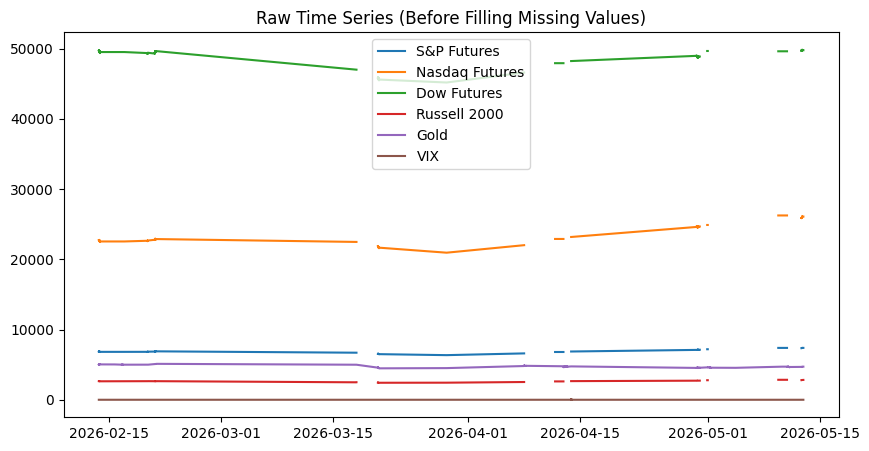

In [24]:
# Plot multiple stock indices over time
plt.figure(figsize=(10,5))

# Plot key columns
plt.plot(df['sp_futures'], label='S&P Futures')
plt.plot(df['nasdaq_futures'], label='Nasdaq Futures')
plt.plot(df['dow_futures'], label='Dow Futures')
plt.plot(df['russell_2000'], label='Russell 2000')
plt.plot(df['gold'], label='Gold')
plt.plot(df['vix'], label='VIX')

# Add legend
plt.legend()

# Title
plt.title("Raw Time Series (Before Filling Missing Values)")

plt.show()

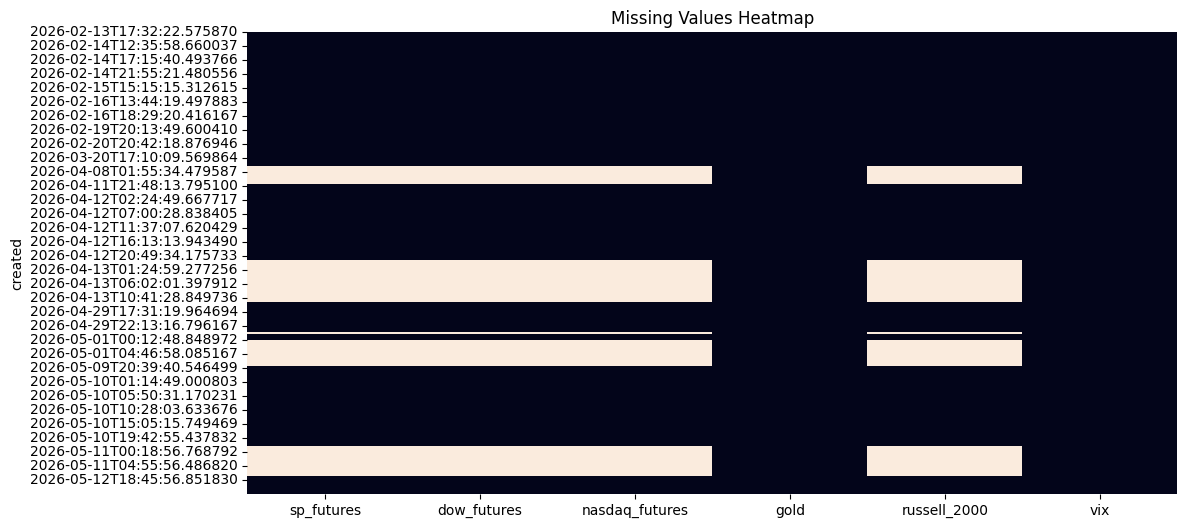

In [25]:
# Visualise missing values across time using Heat maps
plt.figure(figsize=(12,6))

# True = missing
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

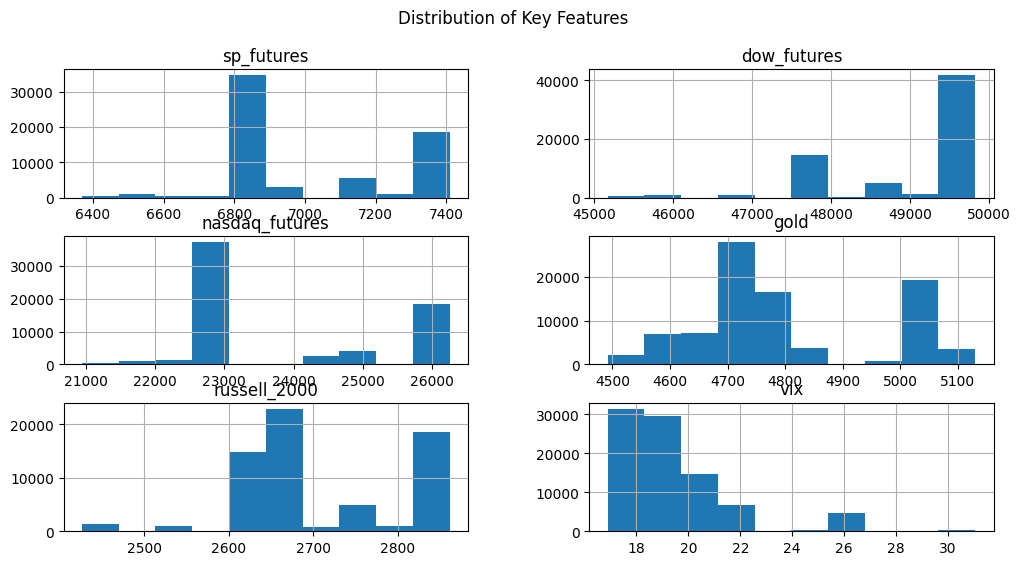

In [26]:
# Plot distribution of key features with missing values 
df.hist(figsize=(12,6))

plt.suptitle("Distribution of Key Features")

plt.show()

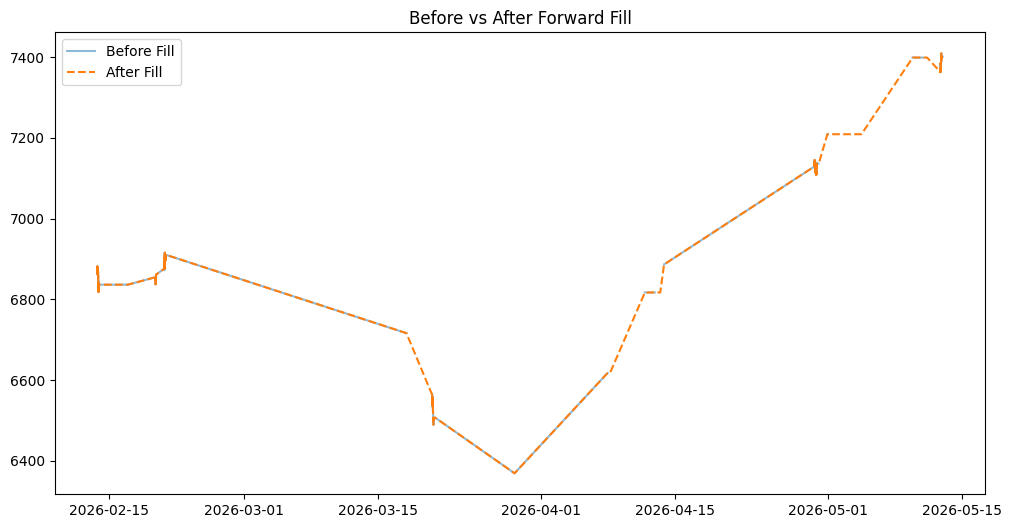

In [27]:
# Create a copy BEFORE filling
df_before = df.copy()

# Apply forward fill
df_after = df.ffill()

# Plot comparison
plt.figure(figsize=(12,6))

plt.plot(df_before['sp_futures'], label='Before Fill', alpha=0.5)
plt.plot(df_after['sp_futures'], label='After Fill', linestyle='--')

plt.legend()
plt.title("Before vs After Forward Fill")

plt.show()

In [28]:
# Forward fill missing values (assumes last price holds)
df = df.ffill()

# RESAMPLE TO FIX TIME INTERVAL

In [29]:
# ==============================
# STEP 3 — RESAMPLE TO FIX TIME INTERVAL
# ==============================

In [30]:
# RESAMPLE TO FIX TIME INTERVAL


# Convert irregular timestamps into hourly intervals
df = df.resample('1h').mean()

# Fill gaps created during resampling
df = df.ffill()


In [31]:
df.isnull().sum()

sp_futures        0
dow_futures       0
nasdaq_futures    0
gold              0
russell_2000      0
vix               0
dtype: int64

In [32]:
df.shape

(2119, 6)

In [33]:
df.head()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix
created,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743


In [34]:
df.tail(25)

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix
created,,,,,,
2026-05-11 23:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 00:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 01:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 02:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 03:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 04:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 05:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 06:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368
2026-05-12 07:00:00+00:00,7398.930000,49609.160000,26247.080000,4676.204211,2861.210000,18.201368


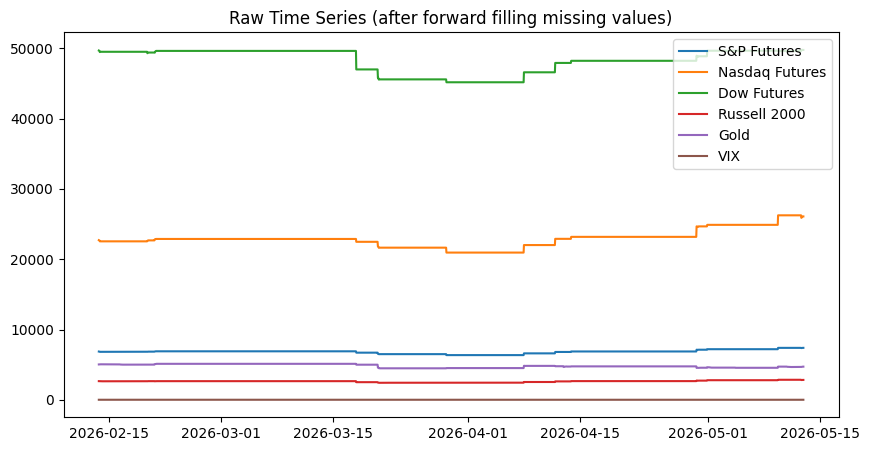

In [35]:
# Plot multiple stock indices over time after forward filling missing values
plt.figure(figsize=(10,5))

# Plot key columns
plt.plot(df['sp_futures'], label='S&P Futures')
plt.plot(df['nasdaq_futures'], label='Nasdaq Futures')
plt.plot(df['dow_futures'], label='Dow Futures')
plt.plot(df['russell_2000'], label='Russell 2000')
plt.plot(df['gold'], label='Gold')
plt.plot(df['vix'], label='VIX')

# Add legend
plt.legend()

# Title
plt.title("Raw Time Series (after forward filling missing values)")

plt.show()

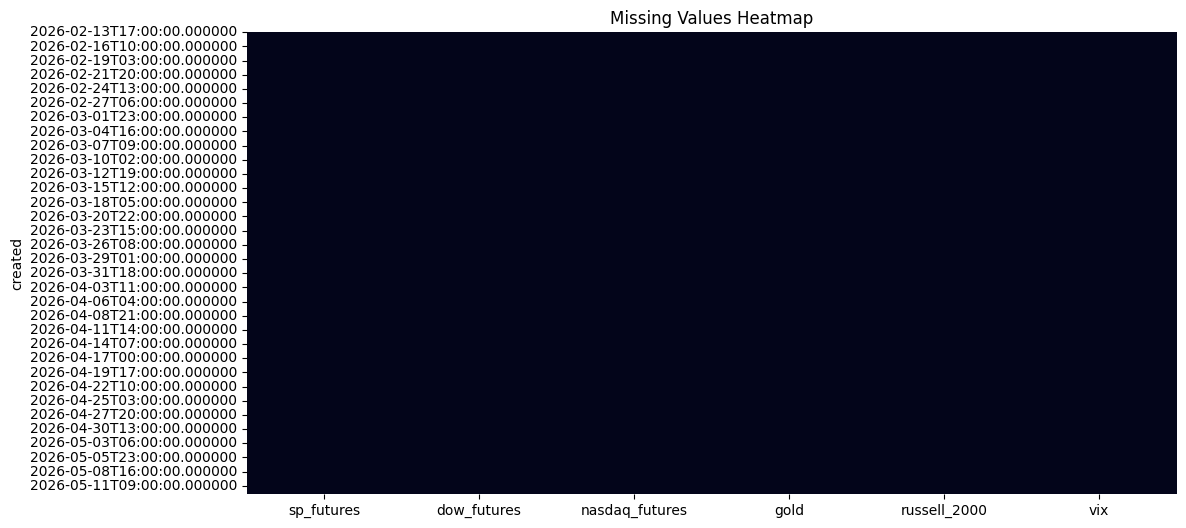

In [36]:
# Visualise missing values across time using Heat maps after forward filling (should show no missing values)
plt.figure(figsize=(12,6))

# True = missing
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

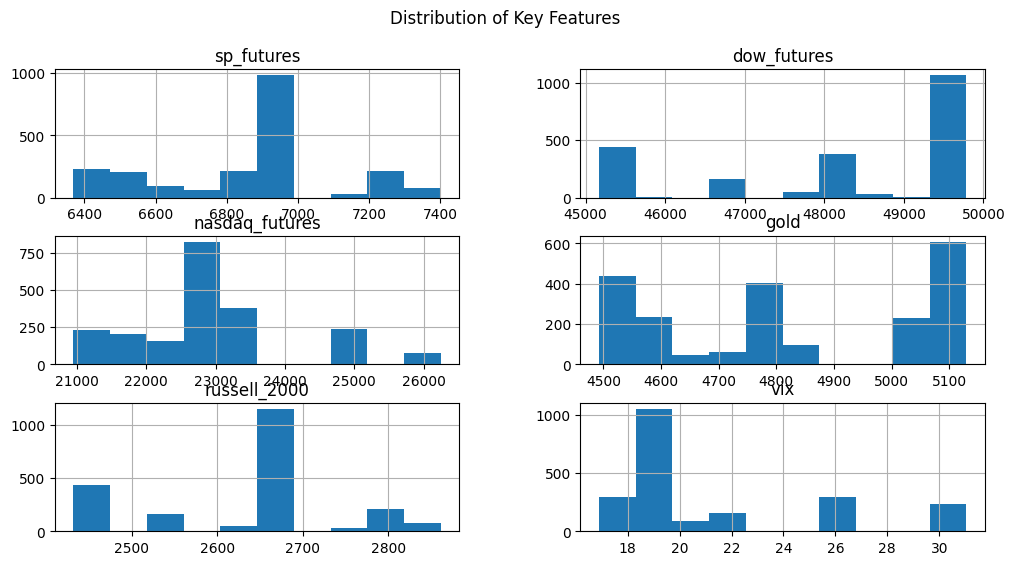

In [37]:
# Plot distribution of key features after filling missing values 
df.hist(figsize=(12,6))

plt.suptitle("Distribution of Key Features")

plt.show()

# FEATURE ENGINEERING

In [38]:
# ==============================
# STEP 4 — FEATURE ENGINEERING
# ==============================

In [39]:
# -------- LAG FEATURES --------
# WHY: Model needs Memory of past values

df['sp_lag_1'] = df['sp_futures'].shift(1)      # 1 step back # Create a new column 'sp_lag_1' that contains the values of 'sp_futures' shifted down by 1 row. This means that for each row, 'sp_lag_1' will contain the value of 'sp_futures' from the previous time step. This is useful for time series models to capture temporal dependencies.
df['sp_lag_3'] = df['sp_futures'].shift(3)      # 3 steps back # Create a new column 'sp_lag_3' that contains the values of 'sp_futures' shifted down by 3 rows. This means that for each row, 'sp_lag_3' will contain the value of 'sp_futures' from three time steps ago. This is useful for time series models to capture longer-term temporal dependencies.
df.head()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3
created,,,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885,NaN,NaN
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346,6876.462192,NaN
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166,6871.563021,NaN
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363,6862.986270,6876.462192
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021


In [40]:
# -------- RETURNS --------
# WHY: Models learn changes better than absolute prices

df['sp_return'] = df['sp_futures'].pct_change()  # Create a new column 'sp_return' that contains the percentage change of 'sp_futures' from the previous time step. This is calculated by taking the current value of 'sp_futures', dividing it by the previous value, and subtracting 1. This feature helps models learn the relative changes in price rather than absolute values, which can improve performance in financial time series forecasting.
df.head()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return
created,,,,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885,NaN,NaN,NaN
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346,6876.462192,NaN,-0.000712
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166,6871.563021,NaN,-0.001248
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363,6862.986270,6876.462192,-0.004220
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021,0.000310


In [41]:
# -------- ROLLING FEATURES --------
# WHY: Capture trend and volatility (important in markets)

df['sp_mean_5'] = df['sp_futures'].rolling(5).mean()  # 5-period rolling mean (trend) # Create a new column 'sp_mean_5' that contains the rolling mean of 'sp_futures' over a window of 5 periods. This means that for each row, 'sp_mean_5' will contain the average value of 'sp_futures' from the current and previous 4 time steps. This feature helps capture the underlying trend in the data, which can be useful for forecasting future values.
df['sp_std_5'] = df['sp_futures'].rolling(5).std()  # 5-period rolling standard deviation (volatility) # Create a new column 'sp_std_5' that contains the rolling standard deviation of 'sp_futures' over a window of 5 periods. This means that for each row, 'sp_std_5' will contain the standard deviation of 'sp_futures' from the current and previous 4 time steps. This feature helps capture the volatility in the data, which can be useful for forecasting future values.
df.head()


,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5
created,,,,,,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885,NaN,NaN,NaN,NaN,NaN
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346,6876.462192,NaN,-0.000712,NaN,NaN
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166,6871.563021,NaN,-0.001248,NaN,NaN
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363,6862.986270,6876.462192,-0.004220,NaN,NaN
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021,0.000310,6856.236556,19.915452


In [42]:
df.tail()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5
created,,,,,,,,,,,
2026-05-12 19:00:00+00:00,7394.446212,49786.867327,26025.364035,4709.648142,2836.302903,18.041080,7378.303392,7398.930000,2.187877e-03,7387.653339,14.033360
2026-05-12 20:00:00+00:00,7400.965569,49760.592084,26088.203678,4721.192469,2843.012102,17.997653,7394.446212,7367.657089,8.816559e-04,7388.060453,14.465169
2026-05-12 21:00:00+00:00,7400.960000,49760.560000,26088.200000,4722.495345,2842.830000,17.990000,7400.965569,7378.303392,-7.524933e-07,7388.466453,14.869361
2026-05-12 22:00:00+00:00,7400.960000,49760.560000,26088.200000,4724.181411,2842.830000,17.990000,7400.960000,7394.446212,0.000000e+00,7395.127035,9.818782
2026-05-12 23:00:00+00:00,7400.960000,49760.560000,26088.200000,4726.847847,2842.830000,17.990000,7400.960000,7400.965569,-1.110223e-16,7399.658356,2.913678


In [43]:
# -------- TIME FEATURES --------
# WHY: Market behaviour depends on time (intraday effects)

df['hour'] = df.index.hour  # Extract hour of day from timestamp and create a new column 'hour'. This feature captures intraday patterns in the data, as market behavior can vary significantly at different times of the day (e.g., opening vs closing hours).
df['day_of_week'] = df.index.dayofweek  # Extract day of week from timestamp and create a new column 'day_of_week'. This feature captures weekly patterns in the data, as market behavior can differ on different days of the week (e.g., Mondays vs Fridays).
df.head()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5,hour,day_of_week
created,,,,,,,,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885,NaN,NaN,NaN,NaN,NaN,17,4
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346,6876.462192,NaN,-0.000712,NaN,NaN,18,4
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166,6871.563021,NaN,-0.001248,NaN,NaN,19,4
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363,6862.986270,6876.462192,-0.004220,NaN,NaN,20,4
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021,0.000310,6856.236556,19.915452,21,4


In [44]:
# -------- CROSS-MARKET FEATURES --------
# WHY: Markets are correlated (S&P influenced by Nasdaq, Dow, etc.)


df['sp_vs_nasdaq'] = df['sp_futures'] - df['nasdaq_futures'] # Create a new column 'sp_vs_nasdaq' that contains the difference between 'sp_futures' and 'nasdaq_futures'. This feature captures the relative performance of S&P futures compared to Nasdaq futures, which can provide additional information for forecasting.
df['sp_vs_dow'] = df['sp_futures'] - df['dow_futures'] # Create a new column 'sp_vs_dow' that contains the difference between 'sp_futures' and 'dow_futures'. This feature captures the relative performance of S&P futures compared to Dow futures, which can provide additional information for forecasting.
df['sp_vs_russell'] = df['sp_futures'] - df['russell_2000'] # Create a new column 'sp_vs_russell' that contains the difference between 'sp_futures' and 'russell_2000'. This feature captures
df.head()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5,hour,day_of_week,sp_vs_nasdaq,sp_vs_dow,sp_vs_russell
created,,,,,,,,,,,,,,,,
2026-02-13 17:00:00+00:00,6876.462192,49685.019385,22718.585231,5042.306923,2665.769231,19.346885,NaN,NaN,NaN,NaN,NaN,17,4,-15842.123038,-42808.557192,4210.692962
2026-02-13 18:00:00+00:00,6871.563021,49664.606219,22699.900406,5047.938516,2662.610106,19.219346,6876.462192,NaN,-0.000712,NaN,NaN,18,4,-15828.337385,-42793.043198,4208.952915
2026-02-13 19:00:00+00:00,6862.986270,49597.417933,22670.086480,5060.534151,2657.232750,19.515166,6871.563021,NaN,-0.001248,NaN,NaN,19,4,-15807.100210,-42734.431664,4205.753520
2026-02-13 20:00:00+00:00,6834.026514,49462.492201,22550.180616,5052.531162,2647.678327,20.513363,6862.986270,6876.462192,-0.004220,NaN,NaN,20,4,-15716.154102,-42628.465687,4186.348187
2026-02-13 21:00:00+00:00,6836.144781,49500.689860,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021,0.000310,6856.236556,19.915452,21,4,-15710.493905,-42664.545079,4189.897320


In [45]:
df.tail()

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5,hour,day_of_week,sp_vs_nasdaq,sp_vs_dow,sp_vs_russell
created,,,,,,,,,,,,,,,,
2026-05-12 19:00:00+00:00,7394.446212,49786.867327,26025.364035,4709.648142,2836.302903,18.041080,7378.303392,7398.930000,2.187877e-03,7387.653339,14.033360,19,1,-18630.917823,-42392.421115,4558.143310
2026-05-12 20:00:00+00:00,7400.965569,49760.592084,26088.203678,4721.192469,2843.012102,17.997653,7394.446212,7367.657089,8.816559e-04,7388.060453,14.465169,20,1,-18687.238109,-42359.626515,4557.953468
2026-05-12 21:00:00+00:00,7400.960000,49760.560000,26088.200000,4722.495345,2842.830000,17.990000,7400.965569,7378.303392,-7.524933e-07,7388.466453,14.869361,21,1,-18687.240000,-42359.600000,4558.130000
2026-05-12 22:00:00+00:00,7400.960000,49760.560000,26088.200000,4724.181411,2842.830000,17.990000,7400.960000,7394.446212,0.000000e+00,7395.127035,9.818782,22,1,-18687.240000,-42359.600000,4558.130000
2026-05-12 23:00:00+00:00,7400.960000,49760.560000,26088.200000,4726.847847,2842.830000,17.990000,7400.960000,7400.965569,-1.110223e-16,7399.658356,2.913678,23,1,-18687.240000,-42359.600000,4558.130000


# TARGET VARIABLE

In [46]:
# ==============================
# STEP 5 — TARGET VARIABLE
# ==============================

In [47]:
# Shift target forward
# WHY: Predict NEXT time step (not current), so shift target variable up by 1 row
df['target'] = df['sp_futures'].shift(-1)  # Create a new column 'target' that contains the values of 'sp_futures' shifted up by 1 row. This means that for each row, 'target' will contain the value of 'sp_futures' from the next time step. This is important because we want to train our model to predict the future value of 'sp_futures', not the current value.

# Drop rows with NaNs
#WHY:
# - Lag features created NaNs at the start -- remeber??
# - Target shift also creates NaN at the end
df = df.dropna()


df.head(25)

,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5,hour,day_of_week,sp_vs_nasdaq,sp_vs_dow,sp_vs_russell,target
created,,,,,,,,,,,,,,,,,
2026-02-13 21:00:00+00:00,6836.144781,49500.68986,22546.638687,5054.671804,2646.247461,20.736743,6834.026514,6871.563021,3.099589e-04,6856.236556,1.991545e+01,21,4,-15710.493905,-42664.545079,4189.89732,6836.17
2026-02-13 22:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.144781,6862.986270,3.689055e-06,6848.178117,1.771581e+01,22,4,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-13 23:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6834.026514,0.000000e+00,6841.099513,1.226995e+01,23,4,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 00:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.144781,0.000000e+00,6835.736259,9.558389e-01,0,5,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 01:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.170000,0.000000e+00,6836.164956,1.127824e-02,1,5,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 02:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.170000,0.000000e+00,6836.170000,0.000000e+00,2,5,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 03:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.170000,0.000000e+00,6836.170000,0.000000e+00,3,5,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 04:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.170000,0.000000e+00,6836.170000,0.000000e+00,4,5,-15710.500000,-42664.760000,4189.47000,6836.17
2026-02-14 05:00:00+00:00,6836.170000,49500.93000,22546.670000,5061.753125,2646.700000,20.600000,6836.170000,6836.170000,0.000000e+00,6836.170000,0.000000e+00,5,5,-15710.500000,-42664.760000,4189.47000,6836.17


In [48]:
df.isnull().sum()

sp_futures        0
dow_futures       0
nasdaq_futures    0
gold              0
russell_2000      0
vix               0
sp_lag_1          0
sp_lag_3          0
sp_return         0
sp_mean_5         0
sp_std_5          0
hour              0
day_of_week       0
sp_vs_nasdaq      0
sp_vs_dow         0
sp_vs_russell     0
target            0
dtype: int64

# FEATURE LIST

In [49]:
# ==============================
# STEP 5 — FEATURE LIST
# ==============================

In [50]:
# Include BOTH raw features and engineered onews as potential inputs for the model. We will let the model figure out which ones are most useful, and we can also do feature selection later if needed.
# WHY: Raw prices + derived signals both add value


features = [
    'sp_futures',
    'nasdaq_futures',
    'dow_futures',
    'russell_2000',
    'vix',
    'gold',

    'sp_lag_1',
    'sp_lag_3',
    'sp_return',
    'sp_mean_5',
    'sp_std_5',

    'hour',
    'day_of_week',

    'sp_vs_nasdaq',
    'sp_vs_dow',
    'sp_vs_russell'
]


X = df[features]        # Create the feature matrix X by selecting the columns specified in the 'features' list from the dataframe df. This matrix will be used as input for training the machine learning model.
y = df['target']        # Create the target vector y by selecting the 'target' column from the dataframe df. This vector contains the values that we want our machine learning model to predict based on the features in X.


In [51]:
X.head()

,sp_futures,nasdaq_futures,dow_futures,russell_2000,vix,gold,sp_lag_1,sp_lag_3,sp_return,sp_mean_5,sp_std_5,hour,day_of_week,sp_vs_nasdaq,sp_vs_dow,sp_vs_russell
created,,,,,,,,,,,,,,,,
2026-02-13 21:00:00+00:00,6836.144781,22546.638687,49500.68986,2646.247461,20.736743,5054.671804,6834.026514,6871.563021,0.000310,6856.236556,19.915452,21,4,-15710.493905,-42664.545079,4189.89732
2026-02-13 22:00:00+00:00,6836.170000,22546.670000,49500.93000,2646.700000,20.600000,5061.753125,6836.144781,6862.986270,0.000004,6848.178117,17.715805,22,4,-15710.500000,-42664.760000,4189.47000
2026-02-13 23:00:00+00:00,6836.170000,22546.670000,49500.93000,2646.700000,20.600000,5061.753125,6836.170000,6834.026514,0.000000,6841.099513,12.269953,23,4,-15710.500000,-42664.760000,4189.47000
2026-02-14 00:00:00+00:00,6836.170000,22546.670000,49500.93000,2646.700000,20.600000,5061.753125,6836.170000,6836.144781,0.000000,6835.736259,0.955839,0,5,-15710.500000,-42664.760000,4189.47000
2026-02-14 01:00:00+00:00,6836.170000,22546.670000,49500.93000,2646.700000,20.600000,5061.753125,6836.170000,6836.170000,0.000000,6836.164956,0.011278,1,5,-15710.500000,-42664.760000,4189.47000


In [52]:
print(X.columns)

Index(['sp_futures', 'nasdaq_futures', 'dow_futures', 'russell_2000', 'vix',
       'gold', 'sp_lag_1', 'sp_lag_3', 'sp_return', 'sp_mean_5', 'sp_std_5',
       'hour', 'day_of_week', 'sp_vs_nasdaq', 'sp_vs_dow', 'sp_vs_russell'],
      dtype='str')


In [53]:
y.head()

created
2026-02-13 21:00:00+00:00    6836.17
2026-02-13 22:00:00+00:00    6836.17
2026-02-13 23:00:00+00:00    6836.17
2026-02-14 00:00:00+00:00    6836.17
2026-02-14 01:00:00+00:00    6836.17
Freq: h, Name: target, dtype: float64

# TIME SPLIT (VERY IMPORTANT)

In [54]:
# ==============================
# STEP 6 — TIME SPLIT (VERY IMPORTANT)
# ==============================

In [55]:
# Print earliest timestamp in dataset
# WHY: Understand where your data starts and ends, especially after all the cleaning and feature engineering steps which can sometimes mess with the index or create unexpected gaps. This also helps you decide how to split your data into training and testing sets based on time.
print(X.index.min())

# Print latest timestamp in dataset
# WHY: Understand where your data ends
print(X.index.max())

2026-02-13 21:00:00+00:00
2026-05-12 22:00:00+00:00


In [56]:
# OPTION A — Manual split (BEST for interviews)

# Define a clear, explainable split date
# WHY: Easy to justify in interviews ("trained on Feb–March, tested on April")
# I HAVE COMMENT THE BELOW, UNCOMMENT IF I WANT TO USE MANUAL SPLIT DATE
split_date = '2026-05-01'  # ← Change this date based on your dataset's time range

print("Auto-selected split date:", split_date)

Auto-selected split date: 2026-05-01


In [57]:
# OPTION B — Automatic 80/20 split

# Calculate index position for 80% of data
# WHY: Automatically splits based on dataset size
##split_index = int(len(X) * 0.8)  # Calculate the index position that corresponds to 80% of the data. This is done by multiplying the total number of rows in X by 0.8 and converting it to an integer.

# Convert index position into actiual timestamp for splitting
# WHY: We need a date (not a computer) for time-based spilts # We take the index of X at the split_index position to get the corresponding timestamp, which we can then use to split our data into training and testing sets based on time.
##split_date = X.index[split_index]  # Get the timestamp at the split_index position from the index of X. This timestamp will be used as the cutoff point for splitting the data into training and testing sets based on time.


##print("Auto-selected split date:", split_date)

In [58]:
# Apply the split (CORE LOGIC)

# Select all rows BEFORE split date for training
# WHY: Model learns only from the past data.            Train on the past, test on the future (time series 101)
X_train = X[X.index < split_date]  # Create the training feature matrix X_train by selecting all rows from X where the index (timestamp) is less than the split_date. This ensures that the model is trained only on past data.

# Match target values for training
y_train = y[y.index < split_date]  # Create the training target vector y_train by selecting all rows from y where the index (timestamp) is less than the split_date. This ensures that the target values correspond to the same time period as the features in X_train.



# Select all rows ON/AFTER split date for testing
# WHY: Simulate PREDICTING unseen future data 
X_test = X[X.index >= split_date]  # Create the testing feature matrix X_test by selecting all rows from X where the index (timestamp) is greater than or equal to the split_date. This simulates predicting unseen future data.

# Match target values for testing
y_test = y[y.index >= split_date]  # Create the testing target vector y_test by selecting all rows from y where the index (timestamp) is greater than or equal to the split


In [59]:
# Verify the split (VERY IMPORTANT)

# Check number of training samples
# WHY: Ensure enough data to train model
print("Training size:", len(X_train))

# Check number of testing samples
# WHY: Ensure test set is not too small
print("Testing size:", len(X_test))


Training size: 1827
Testing size: 287


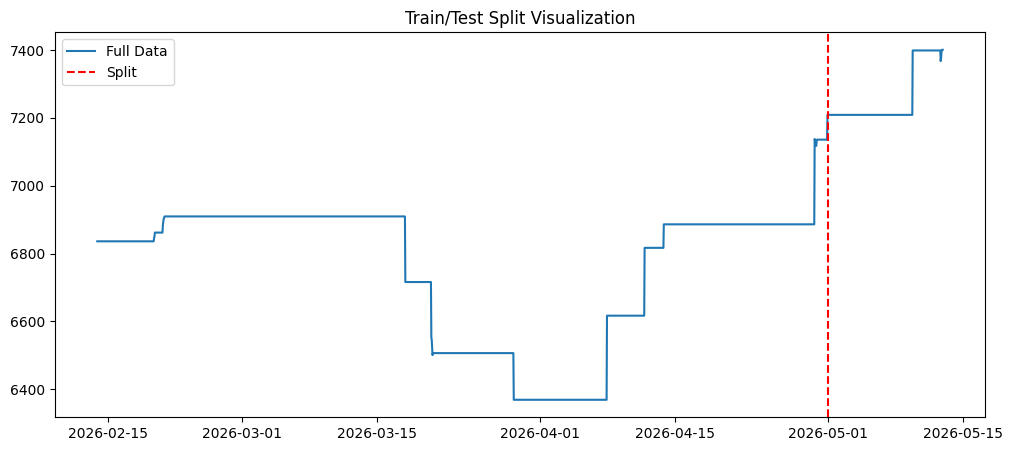

In [60]:
# VISUALISE THE SPLIT (BEST PRACTICE)

# Create plot
plt.figure(figsize=(12,5))

# Plot full time series (S&P futures)
plt.plot(X.index, X['sp_futures'], label='Full Data')

# Draw vertical line at split date
# WHY: Visually shows train/test boundary
plt.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='Split')

# Add legend
plt.legend()

# Add title
plt.title("Train/Test Split Visualization")

# Show plot
plt.show()

# FEATURE SELECTION (RFE, Corr, XGBoost )

In [61]:
# ==============================
# STEP 7 — FEATURE SELECTION (I used 3 different feature selection techniques here: RFE, Correlation-Based, and XGBoost Feature Importance. )
# ==============================

# # I suggest to try all 3 and see which one works best for my dataset and model

# RFE = Recursive Feature Elimination
# Corr = Correlation-Based Selection
# XGB = XGBoost Feature Importance

## Correlation-Based Selection

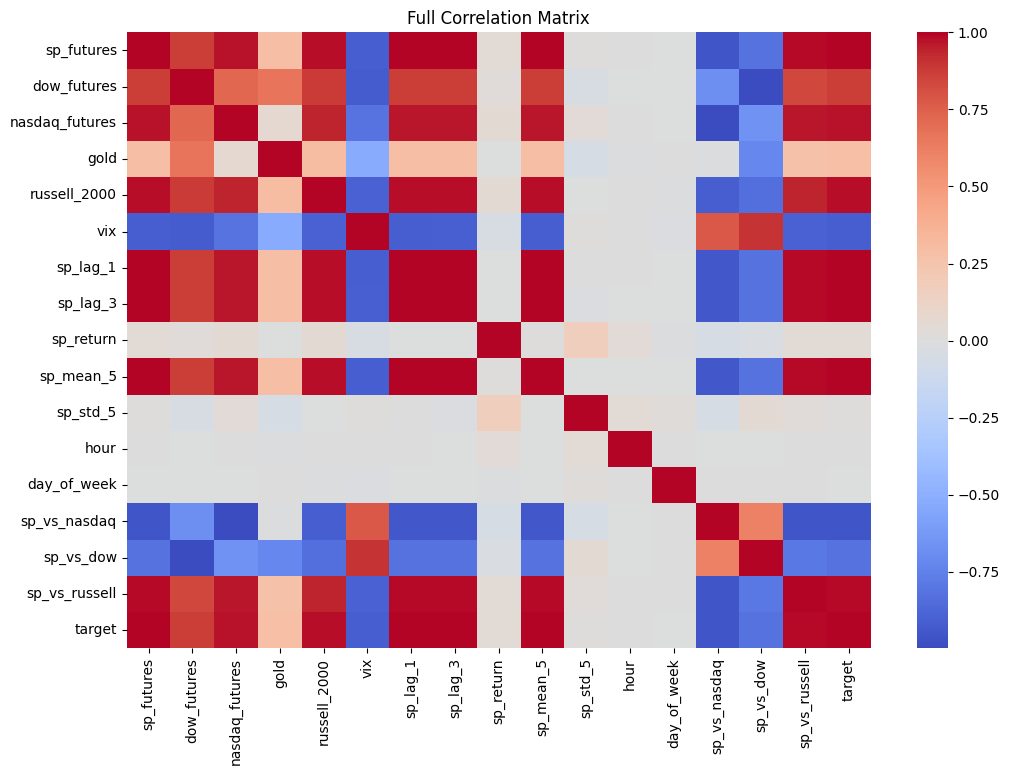

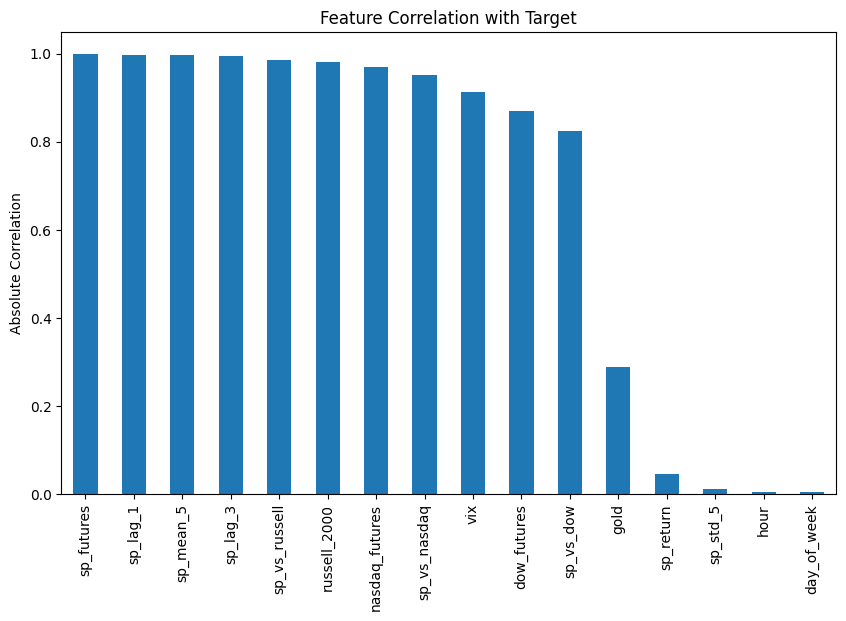

Correlation Selected Features:
           feature  correlation
1       sp_futures     0.998934
2         sp_lag_1     0.997865
3        sp_mean_5     0.997628
4         sp_lag_3     0.995669
5    sp_vs_russell     0.986661
6     russell_2000     0.980905
7   nasdaq_futures     0.969020
8     sp_vs_nasdaq     0.951348
9              vix     0.912296
10     dow_futures     0.869654
11       sp_vs_dow     0.824256
12            gold     0.288713


In [62]:
# ==============================
# CORRELATION FEATURE SELECTION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Full correlation matrix ---
# WHY: Understand relationships between ALL features (multicollinearity)

plt.figure(figsize=(12, 8))

corr_matrix = df.corr()  # compute correlation matrix

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Full Correlation Matrix")

plt.show()


# --- Step 2: Correlation with target ---
# WHY: Identify features that have strongest relationship with target

corr = df.corr()['target'].abs().sort_values(ascending=False)

# Plot correlation with target
plt.figure(figsize=(10,6))

corr.drop('target').plot(kind='bar')

plt.title("Feature Correlation with Target")
plt.ylabel("Absolute Correlation")

plt.show()


# --- Step 3: Select features based on threshold ---
# WHY: Remove weak/noisy features

corr_features = corr[corr > 0.07].index.tolist()

# Remove target if included
corr_features = [f for f in corr_features if f != 'target']


# --- Step 4: Display selected features + scores ---
# WHY: Helps explain why features were chosen

corr_df = corr.reset_index()
corr_df.columns = ['feature', 'correlation']

corr_selected_df = corr_df[corr_df['feature'].isin(corr_features)]

# Sort for clarity
corr_selected_df = corr_selected_df.sort_values(by='correlation', ascending=False)

print("Correlation Selected Features:")
print(corr_selected_df)

## RFE FEATURE SELECTION (WITH EXPLANATION)

RFE Feature Ranking:
           feature  selected  ranking
0       sp_futures      True        1
4              vix      True        1
6         sp_lag_1      True        1
8        sp_return      True        1
14       sp_vs_dow      True        1
2      dow_futures     False        2
1   nasdaq_futures     False        3
13    sp_vs_nasdaq     False        4
3     russell_2000     False        5
15   sp_vs_russell     False        6
12     day_of_week     False        7
11            hour     False        8
10        sp_std_5     False        9
9        sp_mean_5     False       10
7         sp_lag_3     False       11
5             gold     False       12


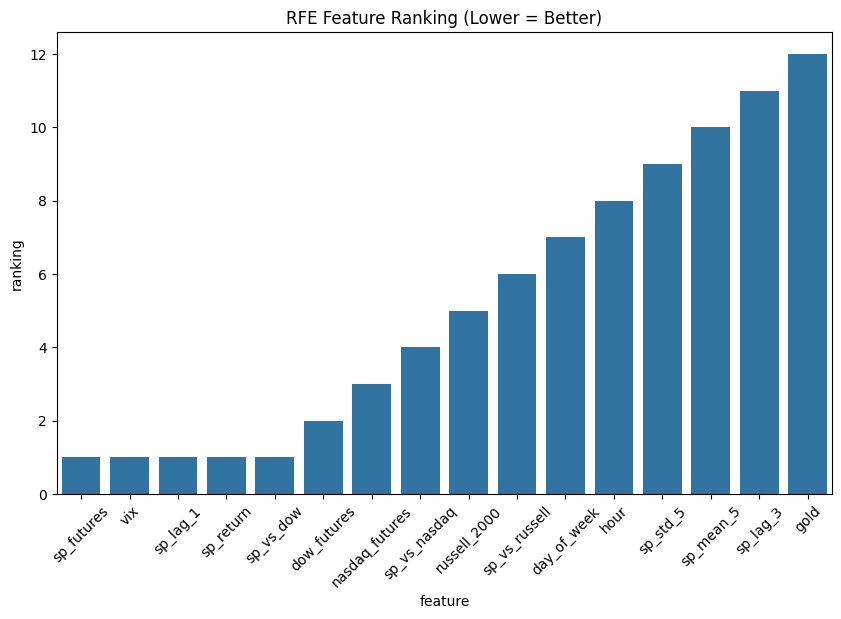

In [63]:
# ==============================
# RFE FEATURE SELECTION
# ==============================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# --- Step 1: Initialise RFE ---
# WHY: Iteratively removes least important features

rfe_selector = RFE(
    estimator=LinearRegression(),   # base model
    n_features_to_select=5          # number of features to keep
)

# --- Step 2: Fit on TRAINING data only ---
# WHY: Avoid data leakage

rfe_selector.fit(X_train, y_train)


# --- Step 3: Extract selected features ---
rfe_features = X_train.columns[rfe_selector.support_].tolist()


# --- Step 4: Create ranking table ---
# WHY: Understand importance of all features

rfe_df = pd.DataFrame({
    'feature': X_train.columns,
    'selected': rfe_selector.support_,   # True = selected
    'ranking': rfe_selector.ranking_     # 1 = best
})

# Sort by ranking (best features first)
rfe_df = rfe_df.sort_values(by='ranking')

print("RFE Feature Ranking:")
print(rfe_df)


# --- Step 5: Visualise selected vs not selected ---
plt.figure(figsize=(10,6))

sns.barplot(
    data=rfe_df,
    x='feature',
    y='ranking'
)

plt.xticks(rotation=45)

plt.title("RFE Feature Ranking (Lower = Better)")

plt.show()

## XGBOOST FEATURE IMPORTANCE (WITH VISUALS)

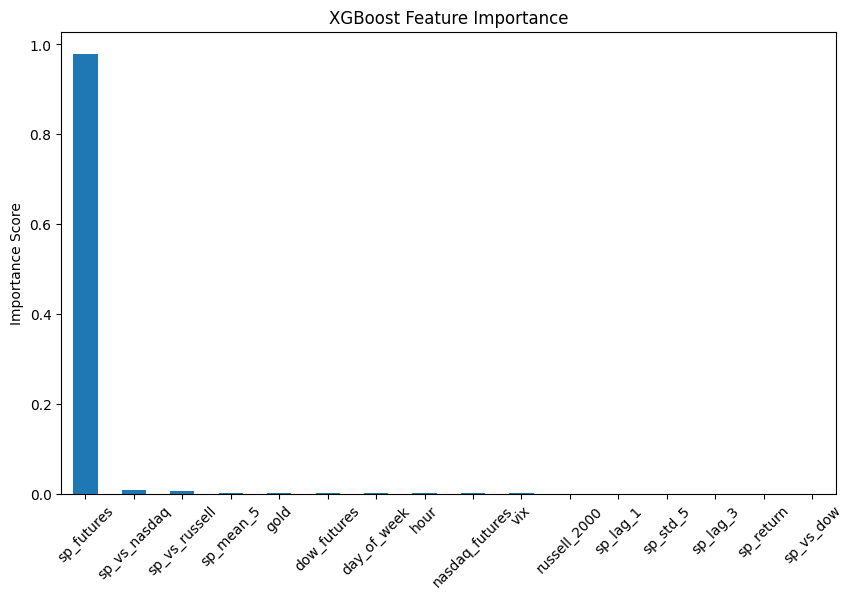

Top XGBoost Features:
sp_futures       0.979363
sp_vs_nasdaq     0.008443
sp_vs_russell    0.006159
sp_mean_5        0.001443
gold             0.001333
dtype: float32


In [64]:
# ==============================
# XGBOOST FEATURE IMPORTANCE
# ==============================

from xgboost import XGBRegressor

# --- Step 1: Train temporary model ---
# WHY: Get feature importance scores

temp_model = XGBRegressor()

temp_model.fit(X_train, y_train)


# --- Step 2: Extract feature importance ---
importances = pd.Series(
    temp_model.feature_importances_,
    index=X_train.columns
)

# Sort features by importance
importances = importances.sort_values(ascending=False)


# --- Step 3: Select top features ---
xgb_features = importances.head(5).index.tolist()


# --- Step 4: Visualise importance ---
plt.figure(figsize=(10,6))

importances.plot(kind='bar')

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()


# --- Step 5: Display selected features ---
print("Top XGBoost Features:")
print(importances.head(5))

# DEFINE FEATURE SETS

In [65]:
# compare different feature strategies

feature_sets = {
    "all_features": features,           # everything
    "correlation": corr_features,       # filtered by correlation
    "rfe": rfe_features,                # selected by RFE
    "xgb_importance": xgb_features      # selected by model importance
}

# Define Models

In [66]:
models = {
    "linear": LinearRegression(),
    "xgboost": XGBRegressor()
}

# CROSS-VALIDATION

In [67]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Store results for each (model + feature set)
results = {}

# Time-aware cross-validation
# WHY:
# Instead of random splits, we simulate real-world forecasting
tscv = TimeSeriesSplit(n_splits=5)


# Loop through each feature set (all, corr, rfe, etc.)
for feature_name, feats in feature_sets.items():

    # Loop through each model (linear, xgboost)
    for model_name, model in models.items():

        # Select only the features for this experiment
        X_tr = X_train[feats]

        # Store train + validation errors for each fold
        train_scores = []
        val_scores = []

        # Time-based splits
        for train_idx, val_idx in tscv.split(X_tr):

            # Split data into TRAIN (past) and VALIDATION (future)
            X_t = X_tr.iloc[train_idx]
            X_val = X_tr.iloc[val_idx]

            y_t = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]


            # ⚠️ Scaling ONLY for linear regression
            if model_name == "linear":

                # Fit scaler on TRAIN only
                scaler = StandardScaler()
                X_t = scaler.fit_transform(X_t)

                # Apply same scaler to validation
                X_val = scaler.transform(X_val)


            # Train model on TRAIN split
            model.fit(X_t, y_t)


            # -------- TRAIN PERFORMANCE --------
            train_preds = model.predict(X_t)

            # Measure how well model fits training data
            train_mse = mean_squared_error(y_t, train_preds)

            train_scores.append(train_mse)


            # -------- VALIDATION PERFORMANCE --------
            val_preds = model.predict(X_val)

            # Measure generalisation performance
            val_mse = mean_squared_error(y_val, val_preds)

            val_scores.append(val_mse)


        # Store average scores across all folds
        results[f"{model_name}_{feature_name}"] = {
            "train_mse": np.mean(train_scores),
            "val_mse": np.mean(val_scores)
        }


# Print results clearly
for k, v in results.items():
    print(f"{k} → Train MSE: {v['train_mse']:.4f}, Val MSE: {v['val_mse']:.4f}")

linear_all_features → Train MSE: 53.3587, Val MSE: 4222.1894
xgboost_all_features → Train MSE: 21.2581, Val MSE: 11103.5064
linear_correlation → Train MSE: 53.5076, Val MSE: 4323.6242
xgboost_correlation → Train MSE: 52.7926, Val MSE: 10588.3621
linear_rfe → Train MSE: 53.8314, Val MSE: 274.3892
xgboost_rfe → Train MSE: 52.8033, Val MSE: 10632.8256
linear_xgb_importance → Train MSE: 53.6788, Val MSE: 2272.7199
xgboost_xgb_importance → Train MSE: 52.7926, Val MSE: 10605.3510


In [68]:
# first results 
